In [ ]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib

# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline


In [ ]:
def skip_first_fn(params):
    skip_first = max(params['tenkan_period'], params['kijun_period'], params['senkou_span_b_period'] + params['chikou_span_delay'])
    return skip_first


def calculate_ichimoku(data, params):
    tenkan_period = params['tenkan_period']
    kijun_period = params['kijun_period']
    senkou_span_b_period = params['senkou_span_b_period']
    chikou_span_delay = params['chikou_span_delay']

    # Tenkan-sen (Conversion Line)
    data['tenkan_sen'] = (data['close'].rolling(window=tenkan_period).max() + 
                          data['close'].rolling(window=tenkan_period).min()) / 2

    # Kijun-sen (Base Line)
    data['kijun_sen'] = (data['close'].rolling(window=kijun_period).max() + 
                         data['close'].rolling(window=kijun_period).min()) / 2

    # Senkou Span A (Leading Span A)
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(chikou_span_delay)

    # Senkou Span B (Leading Span B)
    data['senkou_span_b'] = ((data['close'].rolling(window=senkou_span_b_period).max() + 
                              data['close'].rolling(window=senkou_span_b_period).min()) / 2).shift(chikou_span_delay)

    # Chikou Span (Lagging Span)
    # data['chikou_span'] = data['close'].shift(-chikou_span_delay)
    
    # data['cloud_upper'] = data[['senkou_span_a', 'senkou_span_b']].max(axis=1)
    # data['cloud_lower'] = data[['senkou_span_a', 'senkou_span_b']].min(axis=1)
    
    # data['close_above_cloud'] = data['close'] > data['cloud_upper']
    # data['close_below_cloud'] = data['close'] < data['cloud_lower']
    
    # data['full_bull'] = (
    #     (data['tenkan_sen'] > data['kijun_sen']) &
    #     (data['close_above_cloud']))
    
    # data['full_bear'] = (
    #     (data['tenkan_sen'] < data['kijun_sen']) &
    #     (data['close_below_cloud']))
    

In [ ]:

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = load_candles('binance',asset, quote, timeframe)#['2020':'2024']#.iloc[-35000:-5000]
params = {'tenkan_period': 20, 'kijun_period': 60, 'senkou_span_b_period': 120, 'chikou_span_delay': 30}
calculate_ichimoku(data, params)
skip_first = skip_first_fn(params)
data = data.iloc[skip_first:]
data.head(5)

In [6]:
data

,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b
timestamp,,,,,,,,,
2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455
2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455
2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455
2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455
2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455
...,...,...,...,...,...,...,...,...,...
2024-08-22 00:00:00,61156.03,61229.00,59724.87,60984.31,6786.416910,59348.545,58045.10,59476.7500,61101.100
2024-08-22 08:00:00,60984.31,61400.00,60100.00,60407.40,9948.916940,59613.545,57180.09,59755.5875,61101.100
2024-08-22 16:00:00,60407.39,60707.88,60131.00,60375.84,4505.872030,59613.545,57180.09,59755.5875,61101.100


<a href="https://colab.research.google.com/github/AI4Finance-Foundation/FinRL-Tutorials/blob/master/1-Introduction/Stock_NeurIPS2018_SB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning for Stock Trading from Scratch: Multiple Stock Trading

* **Pytorch Version** 



# Content

* [1. Task Description](#0)
* [2. Install Python packages](#1)
    * [2.1. Install Packages](#1.1)    
    * [2.2. A List of Python Packages](#1.2)
    * [2.3. Import Packages](#1.3)
    * [2.4. Create Folders](#1.4)
* [3. Download and Preprocess Data](#2)
* [4. Preprocess Data](#3)        
    * [4.1. Technical Indicators](#3.1)
    * [4.2. Perform Feature Engineering](#3.2)
* [5. Build Market Environment in OpenAI Gym-style](#4)  
    * [5.1. Data Split](#4.1)  
    * [5.3. Environment for Training](#4.2)    
* [6. Train DRL Agents](#5)
* [7. Backtesting Performance](#6)  
    * [7.1. BackTestStats](#6.1)
    * [7.2. BackTestPlot](#6.2)   
  

<a id='0'></a>
# Part 1. Task Discription

We train a DRL agent for stock trading. This task is modeled as a Markov Decision Process (MDP), and the objective function is maximizing (expected) cumulative return.

We specify the state-action-reward as follows:

* **State s**: The state space represents an agent's perception of the market environment. Just like a human trader analyzing various information, here our agent passively observes many features and learns by interacting with the market environment (usually by replaying historical data).

* **Action a**: The action space includes allowed actions that an agent can take at each state. For example, a ∈ {−1, 0, 1}, where −1, 0, 1 represent
selling, holding, and buying. When an action operates multiple shares, a ∈{−k, ..., −1, 0, 1, ..., k}, e.g.. "Buy
10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or −10, respectively

* **Reward function r(s, a, s′)**: Reward is an incentive for an agent to learn a better policy. For example, it can be the change of the portfolio value when taking a at state s and arriving at new state s',  i.e., r(s, a, s′) = v′ − v, where v′ and v represent the portfolio values at state s′ and s, respectively


**Market environment**: 30 consituent stocks of Dow Jones Industrial Average (DJIA) index. Accessed at the starting date of the testing period.


The data for this case study is obtained from Yahoo Finance API. The data contains Open-High-Low-Close price and volume.


<a id='1'></a>
# Part 2. Install Python Packages

<a id='1.1'></a>
## 2.1. Install packages


In [ ]:
## install required packages
!pip install swig
!pip install wrds
!pip install pyportfolioopt
## install finrl library
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# !apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git


<a id='1.2'></a>
## 2.2. A list of Python packages 
* Yahoo Finance API
* pandas
* numpy
* matplotlib
* stockstats
* OpenAI gym
* stable-baselines
* tensorflow
* pyfolio

<a id='1.3'></a>
## 2.3. Import Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

import sys
sys.path.append("../../FinRL")

%matplotlib inline
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl.meta.data_processor import DataProcessor

from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline
from pprint import pprint


import itertools

<a id='1.4'></a>
## 2.4. Create Folders

In [ ]:
from finrl import config
from finrl import config_tickers
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)
check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])



<a id='2'></a>
# Part 3. Download Data
Yahoo Finance provides stock data, financial news, financial reports, etc. Yahoo Finance is free.
* FinRL uses a class **YahooDownloader** in FinRL-Meta to fetch data via Yahoo Finance API
* Call Limit: Using the Public API (without authentication), you are limited to 2,000 requests per hour per IP (or up to a total of 48,000 requests a day).



-----
class YahooDownloader:
    Retrieving daily stock data from
    Yahoo Finance API

    Attributes
    ----------
        start_date : str
            start date of the data (modified from config.py)
        end_date : str
            end date of the data (modified from config.py)
        ticker_list : list
            a list of stock tickers (modified from config.py)

    Methods
    -------
    fetch_data()


In [ ]:
# from config.py, TRAIN_START_DATE is a string
TRAIN_START_DATE
# from config.py, TRAIN_END_DATE is a string
TRAIN_END_DATE

In [7]:
TRAIN_START_DATE = '2017-10-01'
TRAIN_END_DATE = '2021-10-01'
TRADE_START_DATE = '2021-10-01'
TRADE_END_DATE = '2025-03-01'

In [ ]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = config_tickers.DOW_30_TICKER).fetch_data()

In [ ]:
print(config_tickers.DOW_30_TICKER)

In [29]:
df = data.copy().assign(tic=asset).reset_index().rename({'timestamp': 'date'}, axis=1)
# df['tic'] = asset
df

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455,BTC
1,2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455,BTC
2,2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455,BTC
3,2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455,BTC
4,2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455,BTC
...,...,...,...,...,...,...,...,...,...,...,...
7533,2024-08-22 00:00:00,61156.03,61229.00,59724.87,60984.31,6786.416910,59348.545,58045.10,59476.7500,61101.100,BTC
7534,2024-08-22 08:00:00,60984.31,61400.00,60100.00,60407.40,9948.916940,59613.545,57180.09,59755.5875,61101.100,BTC
7535,2024-08-22 16:00:00,60407.39,60707.88,60131.00,60375.84,4505.872030,59613.545,57180.09,59755.5875,61101.100,BTC
7536,2024-08-23 00:00:00,60375.83,61367.74,60342.14,61069.27,5121.625480,59791.690,57180.09,59755.5875,61101.100,BTC


In [30]:
df.reset_index()

,index,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,0,2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455,BTC
1,1,2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455,BTC
2,2,2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455,BTC
3,3,2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455,BTC
4,4,2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455,BTC
...,...,...,...,...,...,...,...,...,...,...,...,...
7533,7533,2024-08-22 00:00:00,61156.03,61229.00,59724.87,60984.31,6786.416910,59348.545,58045.10,59476.7500,61101.100,BTC
7534,7534,2024-08-22 08:00:00,60984.31,61400.00,60100.00,60407.40,9948.916940,59613.545,57180.09,59755.5875,61101.100,BTC
7535,7535,2024-08-22 16:00:00,60407.39,60707.88,60131.00,60375.84,4505.872030,59613.545,57180.09,59755.5875,61101.100,BTC
7536,7536,2024-08-23 00:00:00,60375.83,61367.74,60342.14,61069.27,5121.625480,59791.690,57180.09,59755.5875,61101.100,BTC


In [31]:
df.sort_values(['date','tic'],ignore_index=True).head()

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455,BTC
1,2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455,BTC
2,2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455,BTC
3,2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455,BTC
4,2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455,BTC


# Part 4: Preprocess Data
We need to check for missing data and do feature engineering to convert the data point into a state.
* **Adding technical indicators**. In practical trading, various information needs to be taken into account, such as historical prices, current holding shares, technical indicators, etc. Here, we demonstrate two trend-following technical indicators: MACD and RSI.
* **Adding turbulence index**. Risk-aversion reflects whether an investor prefers to protect the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007–2008, FinRL employs the turbulence index that measures extreme fluctuation of asset price.

In [33]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'tenkan_sen',
       'kijun_sen', 'senkou_span_a', 'senkou_span_b', 'tic'],
      dtype='object')

In [44]:
INDICATORS = ichi_indicators = ['open', 'high', 'low', 'close', 'volume', 'tenkan_sen', 'kijun_sen',
       'senkou_span_a', 'senkou_span_b']
fe = FeatureEngineer(
                    use_technical_indicator=False,
                    tech_indicator_list = ichi_indicators, #INDICATORS,
                    use_vix=False,
                    use_turbulence=False,
                    user_defined_feature = False)

processed = fe.preprocess_data(df)

In [45]:
processed

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455,BTC
1,2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455,BTC
2,2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455,BTC
3,2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455,BTC
4,2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455,BTC
...,...,...,...,...,...,...,...,...,...,...,...
7533,2024-08-22 00:00:00,61156.03,61229.00,59724.87,60984.31,6786.416910,59348.545,58045.10,59476.7500,61101.100,BTC
7534,2024-08-22 08:00:00,60984.31,61400.00,60100.00,60407.40,9948.916940,59613.545,57180.09,59755.5875,61101.100,BTC
7535,2024-08-22 16:00:00,60407.39,60707.88,60131.00,60375.84,4505.872030,59613.545,57180.09,59755.5875,61101.100,BTC
7536,2024-08-23 00:00:00,60375.83,61367.74,60342.14,61069.27,5121.625480,59791.690,57180.09,59755.5875,61101.100,BTC


In [46]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])

processed_full = processed_full.fillna(0)

ValueError: You are trying to merge on object and datetime64[ns] columns for key 'date'. If you wish to proceed you should use pd.concat

In [47]:
processed_full.sort_values(['date','tic'],ignore_index=True).head(10)

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.040,3855.5175,3991.455,BTC
1,2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.040,3855.5175,3991.455,BTC
2,2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.040,3855.5175,3991.455,BTC
3,2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.040,3846.2675,3991.455,BTC
4,2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.040,3860.9200,3991.455,BTC
5,2017-10-07 16:00:00,4343.01,4479.50,4326.02,4423.00,98.785433,4289.055,3969.040,3868.5200,3991.455,BTC
6,2017-10-08 00:00:00,4425.00,4517.00,4425.00,4455.99,135.996632,4305.045,3985.030,3817.2675,3991.455,BTC
7,2017-10-08 08:00:00,4454.99,4599.00,4441.01,4590.00,201.662109,4372.050,4052.035,3817.2675,3991.455,BTC
8,2017-10-08 16:00:00,4590.00,4658.00,4525.00,4640.00,180.803263,4397.050,4077.035,3817.2675,3991.455,BTC
9,2017-10-09 00:00:00,4640.00,4660.00,4550.00,4584.06,150.503513,4397.050,4077.035,3837.7175,3991.455,BTC


In [48]:
mvo_df = processed_full.sort_values(['date','tic'],ignore_index=True)[['date','tic','close']]

<a id='4'></a>
# Part 5. Build A Market Environment in OpenAI Gym-style
The training process involves observing stock price change, taking an action and reward's calculation. By interacting with the market environment, the agent will eventually derive a trading strategy that may maximize (expected) rewards.

Our market environment, based on OpenAI Gym, simulates stock markets with historical market data.

## Data Split
We split the data into training set and testing set as follows:

Training data period: 2009-01-01 to 2020-07-01

Trading data period: 2020-07-01 to 2021-10-31


In [49]:
processed_full = processed
train = data_split(processed_full, TRAIN_START_DATE,TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE,TRADE_END_DATE)
train_length = len(train)
trade_length = len(trade)
print(train_length)
print(trade_length)

4365
3173


In [50]:
train.tail()

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
4360,2021-09-29 08:00:00,42442.00,42590.00,41619.99,41698.98,11444.62775,42945.90,44678.195,47502.1325,48430.045,BTC
4361,2021-09-29 16:00:00,41698.97,41824.01,40900.00,41524.28,10650.46859,42945.90,44678.195,47502.1325,48430.045,BTC
4362,2021-09-30 00:00:00,41524.29,43830.00,41410.17,43286.88,16597.48196,42945.90,44678.195,47618.0275,48430.045,BTC
4363,2021-09-30 08:00:00,43286.88,43777.00,42697.01,43149.02,16975.54346,42922.50,44678.195,47243.9175,48254.390,BTC
4364,2021-09-30 16:00:00,43149.02,44141.37,42819.86,43824.10,12808.20239,42425.32,44678.195,46829.2875,47839.760,BTC


In [51]:
trade.head()

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,2021-10-01 00:00:00,43820.01,44836.00,43283.03,44788.42,14136.01554,42907.480,44678.195,46829.2875,47839.76,BTC
1,2021-10-01 08:00:00,44788.42,47886.11,44700.00,47363.68,36433.41334,44195.110,44678.195,46829.2875,47839.76,BTC
2,2021-10-01 16:00:00,47363.69,48495.00,47232.98,48141.61,15675.44604,44584.075,44678.195,45688.6675,46699.14,BTC
3,2021-10-02 00:00:00,48141.60,48224.01,47430.18,47725.01,10573.51925,44584.075,44678.195,45688.6675,46699.14,BTC
4,2021-10-02 08:00:00,47725.00,48336.59,47478.44,47828.52,10553.38245,44584.075,44678.195,45688.6675,46699.14,BTC


In [52]:
INDICATORS

['open',
 'high',
 'low',
 'close',
 'volume',
 'tenkan_sen',
 'kijun_sen',
 'senkou_span_a',
 'senkou_span_b']

In [53]:
stock_dimension = len(train.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 1, State Space: 12


In [54]:
buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,
    "sell_cost_pct": sell_cost_list,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}


e_train_gym = StockTradingEnv(df = train, **env_kwargs)

## Environment for Training



In [55]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


<a id='5'></a>
# Part 6: Train DRL Agents
* The DRL algorithms are from **Stable Baselines 3**. Users are also encouraged to try **ElegantRL** and **Ray RLlib**.
* FinRL includes fine-tuned standard DRL algorithms, such as DQN, DDPG, Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

In [56]:
agent = DRLAgent(env = env_train)

if_using_a2c = False
if_using_ddpg = False
if_using_ppo = True
if_using_td3 = False
if_using_sac = False


### Agent Training: 5 algorithms (A2C, DDPG, PPO, TD3, SAC)


### Agent 1: A2C


In [ ]:
agent = DRLAgent(env = env_train)
model_a2c = agent.get_model("a2c")

if if_using_a2c:
  # set up logger
  tmp_path = RESULTS_DIR + '/a2c'
  new_logger_a2c = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_a2c.set_logger(new_logger_a2c)


In [ ]:
trained_a2c = agent.train_model(model=model_a2c, 
                             tb_log_name='a2c',
                             total_timesteps=50000) if if_using_a2c else None

### Agent 2: DDPG

In [ ]:
agent = DRLAgent(env = env_train)
model_ddpg = agent.get_model("ddpg")

if if_using_ddpg:
  # set up logger
  tmp_path = RESULTS_DIR + '/ddpg'
  new_logger_ddpg = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_ddpg.set_logger(new_logger_ddpg)

In [ ]:
trained_ddpg = agent.train_model(model=model_ddpg, 
                             tb_log_name='ddpg',
                             total_timesteps=50000) if if_using_ddpg else None

### Agent 3: PPO

In [57]:
agent = DRLAgent(env = env_train)
PPO_PARAMS = {
    "n_steps": 2048,
    "ent_coef": 0.01,
    "learning_rate": 0.00025,
    "batch_size": 128,
}
model_ppo = agent.get_model("ppo",model_kwargs = PPO_PARAMS)

if if_using_ppo:
  # set up logger
  tmp_path = RESULTS_DIR + '/ppo'
  new_logger_ppo = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_ppo.set_logger(new_logger_ppo)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 128}
Using cpu device
Logging to results/ppo


In [58]:
trained_ppo = agent.train_model(model=model_ppo, 
                             tb_log_name='ppo',
                             total_timesteps=50000) if if_using_ppo else None

-----------------------------------
| time/              |            |
|    fps             | 1997       |
|    iterations      | 1          |
|    time_elapsed    | 1          |
|    total_timesteps | 2048       |
| train/             |            |
|    reward          | -0.0137977 |
-----------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1583         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0018336733 |
|    clip_fraction        | 0.00977      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.000106     |
|    learning_rate        | 0.00025      |
|    loss                 | 13.8         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.

### Agent 4: TD3

In [ ]:
agent = DRLAgent(env = env_train)
TD3_PARAMS = {"batch_size": 100, 
              "buffer_size": 1000000, 
              "learning_rate": 0.001}

model_td3 = agent.get_model("td3",model_kwargs = TD3_PARAMS)

if if_using_td3:
  # set up logger
  tmp_path = RESULTS_DIR + '/td3'
  new_logger_td3 = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_td3.set_logger(new_logger_td3)

In [ ]:
trained_td3 = agent.train_model(model=model_td3, 
                             tb_log_name='td3',
                             total_timesteps=50000) if if_using_td3 else None

### Agent 5: SAC

In [ ]:
agent = DRLAgent(env = env_train)
SAC_PARAMS = {
    "batch_size": 128,
    "buffer_size": 100000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

model_sac = agent.get_model("sac",model_kwargs = SAC_PARAMS)

if if_using_sac:
  # set up logger
  tmp_path = RESULTS_DIR + '/sac'
  new_logger_sac = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_sac.set_logger(new_logger_sac)

In [ ]:
trained_sac = agent.train_model(model=model_sac, 
                             tb_log_name='sac',
                             total_timesteps=50000) if if_using_sac else None

## In-sample Performance

Assume that the initial capital is $1,000,000.

### Set turbulence threshold
Set the turbulence threshold to be greater than the maximum of insample turbulence data. If current turbulence index is greater than the threshold, then we assume that the current market is volatile

In [59]:
data_risk_indicator = processed_full[(processed_full.date<TRAIN_END_DATE) & (processed_full.date>=TRAIN_START_DATE)]
insample_risk_indicator = data_risk_indicator.drop_duplicates(subset=['date'])

In [60]:
insample_risk_indicator.vix.describe()

AttributeError: 'DataFrame' object has no attribute 'vix'

In [61]:
insample_risk_indicator.vix.quantile(0.996)

AttributeError: 'DataFrame' object has no attribute 'vix'

In [62]:
insample_risk_indicator.turbulence.describe()

AttributeError: 'DataFrame' object has no attribute 'turbulence'

In [63]:
insample_risk_indicator.turbulence.quantile(0.996)

AttributeError: 'DataFrame' object has no attribute 'turbulence'

### Trading (Out-of-sample Performance)

We update periodically in order to take full advantage of the data, e.g., retrain quarterly, monthly or weekly. We also tune the parameters along the way, in this notebook we use the in-sample data from 2009-01 to 2020-07 to tune the parameters once, so there is some alpha decay here as the length of trade date extends. 

Numerous hyperparameters – e.g. the learning rate, the total number of samples to train on – influence the learning process and are usually determined by testing some variations.

In [69]:
# e_trade_gym = StockTradingEnv(df = trade, turbulence_threshold = 70,risk_indicator_col='vix', **env_kwargs)
e_trade_gym = StockTradingEnv(df = trade, turbulence_threshold = None,risk_indicator_col=None, **env_kwargs)
# env_trade, obs_trade = e_trade_gym.get_sb_env()

In [70]:
trade.head()

,date,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,tic
0,2021-10-01 00:00:00,43820.01,44836.00,43283.03,44788.42,14136.01554,42907.480,44678.195,46829.2875,47839.76,BTC
1,2021-10-01 08:00:00,44788.42,47886.11,44700.00,47363.68,36433.41334,44195.110,44678.195,46829.2875,47839.76,BTC
2,2021-10-01 16:00:00,47363.69,48495.00,47232.98,48141.61,15675.44604,44584.075,44678.195,45688.6675,46699.14,BTC
3,2021-10-02 00:00:00,48141.60,48224.01,47430.18,47725.01,10573.51925,44584.075,44678.195,45688.6675,46699.14,BTC
4,2021-10-02 08:00:00,47725.00,48336.59,47478.44,47828.52,10553.38245,44584.075,44678.195,45688.6675,46699.14,BTC


In [ ]:
trained_moedl = trained_a2c
df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_moedl, 
    environment = e_trade_gym)

In [ ]:
trained_moedl = trained_ddpg
df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
    model=trained_moedl, 
    environment = e_trade_gym)

In [71]:
trained_moedl = trained_ppo
df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_moedl, 
    environment = e_trade_gym)

hit end!


In [80]:
df_actions_ppo.actions.describe()

count     3172
unique       2
top        [0]
freq      3171
Name: actions, dtype: object

In [ ]:
%matplotlib inline
df_account_value_ppo
df_result_ppo = df_account_value_ppo.set_index('date')
plt.rcParams["figure.figsize"] = (20,7)
plt.figure();
# result.plot();
df_result_ppo.plot();


In [ ]:
trained_moedl = trained_td3
df_account_value_td3, df_actions_td3 = DRLAgent.DRL_prediction(
    model=trained_moedl, 
    environment = e_trade_gym)

In [ ]:
trained_moedl = trained_sac
df_account_value_sac, df_actions_sac = DRLAgent.DRL_prediction(
    model=trained_moedl, 
    environment = e_trade_gym)

In [ ]:
df_account_value_a2c.shape

,date,account_value
0,2021-10-01 00:00:00,1.000000e+06
1,2021-10-01 08:00:00,1.055670e+06
2,2021-10-01 16:00:00,1.072785e+06
3,2021-10-02 00:00:00,1.063620e+06
4,2021-10-02 08:00:00,1.065897e+06
...,...,...
3168,2024-08-22 00:00:00,1.355324e+06
3169,2024-08-22 08:00:00,1.342632e+06
3170,2024-08-22 16:00:00,1.341938e+06
3171,2024-08-23 00:00:00,1.357193e+06


<Figure size 2000x700 with 0 Axes>

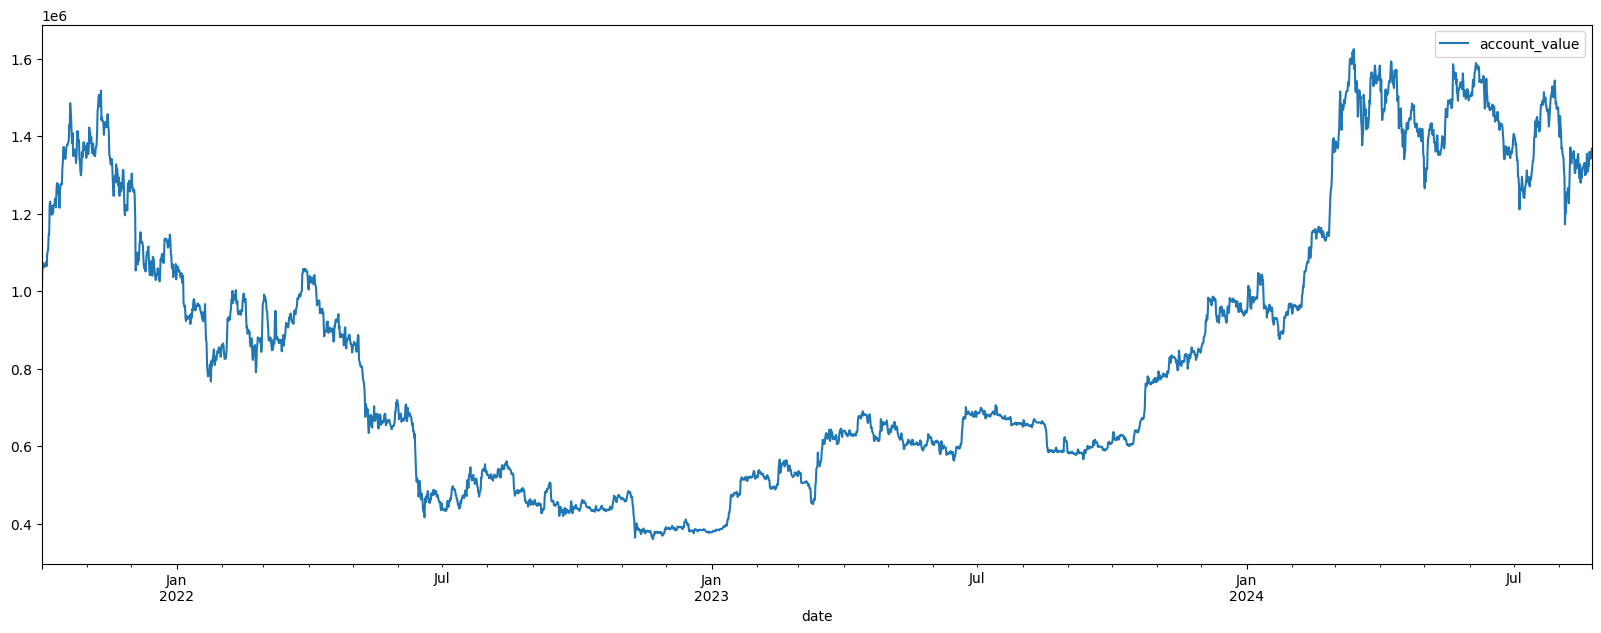

<a id='7'></a>
# Part 6.5: Mean Variance Optimization

Mean Variance optimization is a very classic strategy in portfolio management. Here, we go through the whole process to do the mean variance optimization and add it as a baseline to compare.

First, process dataframe to the form for MVO weight calculation.

In [ ]:
def process_df_for_mvo(df):
  df = df.sort_values(['date','tic'],ignore_index=True)[['date','tic','close']]
  fst = df
  fst = fst.iloc[0:stock_dimension, :]
  tic = fst['tic'].tolist()

  mvo = pd.DataFrame()

  for k in range(len(tic)):
    mvo[tic[k]] = 0

  for i in range(df.shape[0]//stock_dimension):
    n = df
    n = n.iloc[i * stock_dimension:(i+1) * stock_dimension, :]
    date = n['date'][i*stock_dimension]
    mvo.loc[date] = n['close'].tolist()
  
  return mvo

### Helper functions for mean returns and variance-covariance matrix

In [ ]:
# Codes in this section partially refer to Dr G A Vijayalakshmi Pai

# https://www.kaggle.com/code/vijipai/lesson-5-mean-variance-optimization-of-portfolios/notebook

def StockReturnsComputing(StockPrice, Rows, Columns): 
  import numpy as np 
  StockReturn = np.zeros([Rows-1, Columns]) 
  for j in range(Columns):        # j: Assets 
    for i in range(Rows-1):     # i: Daily Prices 
      StockReturn[i,j]=((StockPrice[i+1, j]-StockPrice[i,j])/StockPrice[i,j])* 100 
      
  return StockReturn

### Calculate the weights for mean-variance

In [ ]:
train_mvo = data_split(processed_full, TRAIN_START_DATE,TRAIN_END_DATE).reset_index()
trade_mvo = data_split(processed_full, TRADE_START_DATE,TRADE_END_DATE).reset_index()

In [ ]:
StockData = process_df_for_mvo(train_mvo)
TradeData = process_df_for_mvo(trade_mvo)

TradeData.to_numpy()

In [ ]:
#compute asset returns
arStockPrices = np.asarray(StockData)
[Rows, Cols]=arStockPrices.shape
arReturns = StockReturnsComputing(arStockPrices, Rows, Cols)

#compute mean returns and variance covariance matrix of returns
meanReturns = np.mean(arReturns, axis = 0)
covReturns = np.cov(arReturns, rowvar=False)
 
#set precision for printing results
np.set_printoptions(precision=3, suppress = True)

#display mean returns and variance-covariance matrix of returns
print('Mean returns of assets in k-portfolio 1\n', meanReturns)
print('Variance-Covariance matrix of returns\n', covReturns)

### Use PyPortfolioOpt

In [ ]:
from pypfopt.efficient_frontier import EfficientFrontier

ef_mean = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 0.5))
raw_weights_mean = ef_mean.max_sharpe()
cleaned_weights_mean = ef_mean.clean_weights()
mvo_weights = np.array([1000000 * cleaned_weights_mean[i] for i in range(29)])
mvo_weights

In [ ]:
LastPrice = np.array([1/p for p in StockData.tail(1).to_numpy()[0]])
Initial_Portfolio = np.multiply(mvo_weights, LastPrice)
Initial_Portfolio

In [ ]:
Portfolio_Assets = TradeData @ Initial_Portfolio
MVO_result = pd.DataFrame(Portfolio_Assets, columns=["Mean Var"])
# MVO_result

<a id='6'></a>
# Part 7: Backtesting Results
Backtesting plays a key role in evaluating the performance of a trading strategy. Automated backtesting tool is preferred because it reduces the human error. We usually use the Quantopian pyfolio package to backtest our trading strategies. It is easy to use and consists of various individual plots that provide a comprehensive image of the performance of a trading strategy.

In [ ]:
# df_result_a2c = df_account_value_a2c.set_index(df_account_value_a2c.columns[0])
# df_result_a2c.rename(columns = {'account_value':'a2c'}, inplace = True)
# df_result_ddpg = df_account_value_ddpg.set_index(df_account_value_ddpg.columns[0])
# df_result_ddpg.rename(columns = {'account_value':'ddpg'}, inplace = True)
# df_result_td3 = df_account_value_td3.set_index(df_account_value_td3.columns[0])
# df_result_td3.rename(columns = {'account_value':'td3'}, inplace = True)
df_result_ppo = df_account_value_ppo.set_index(df_account_value_ppo.columns[0])
df_result_ppo.rename(columns = {'account_value':'ppo'}, inplace = True)
# df_result_sac = df_account_value_sac.set_index(df_account_value_sac.columns[0])
# df_result_sac.rename(columns = {'account_value':'sac'}, inplace = True)
# df_account_value_a2c.to_csv("df_account_value_a2c.csv")
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI", 
        start = TRADE_START_DATE,
        end = TRADE_END_DATE)
stats = backtest_stats(df_dji_, value_col_name = 'close')
df_dji = pd.DataFrame()
# df_dji['date'] = df_account_value_a2c['date']
df_dji['account_value'] = df_dji_['close'] / df_dji_['close'][0] * env_kwargs["initial_amount"]
df_dji.to_csv("df_dji.csv")
df_dji = df_dji.set_index(df_dji.columns[0])
df_dji.to_csv("df_dji+.csv")

result = pd.DataFrame()
# result = pd.merge(result, df_result_a2c, how='outer', left_index=True, right_index=True)
# result = pd.merge(result, df_result_ddpg, how='outer', left_index=True, right_index=True)
# result = pd.merge(result, df_result_td3, how='outer', left_index=True, right_index=True)
result = pd.merge(result, df_result_ppo, how='outer', left_index=True, right_index=True)
# result = pd.merge(result, df_result_sac, how='outer', left_index=True, right_index=True)
# result = pd.merge(result, MVO_result, how='outer', left_index=True, right_index=True)
print(result.head())
# result = pd.merge(result, df_dji, how='outer', left_index=True, right_index=True)
# result.columns = ['a2c', 'ddpg', 'td3', 'ppo', 'sac', 'mean var', 'dji']

# print("result: ", result)
result.to_csv("result.csv")

In [ ]:
df_result_ddpg

NameError: name 'df_result_ppo' is not defined

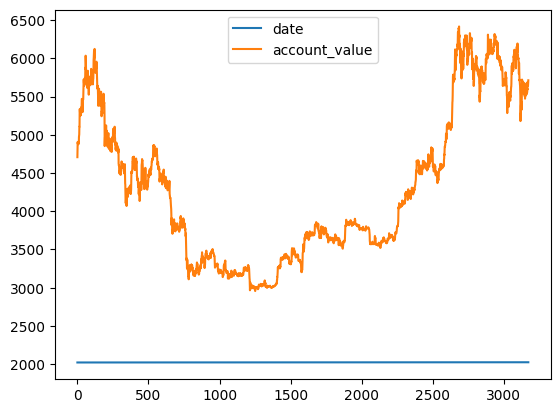

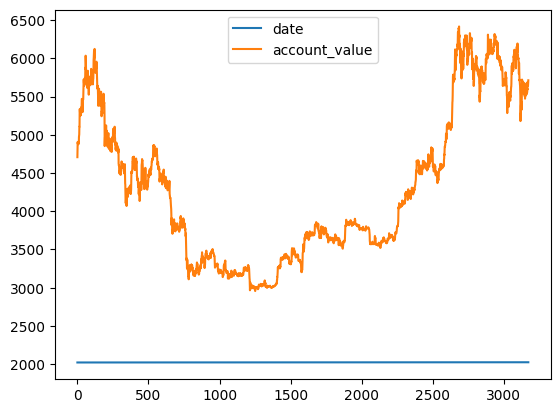

<Figure size 2000x700 with 0 Axes>

In [76]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (20,7)
plt.figure();
# result.plot();
df_result_ppo.plot();